In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Import datasets

In [2]:
adverse_reactions = pd.read_csv('adverse_reactions.csv')
patients = pd.read_csv('patients.csv')
treatments_cut = pd.read_csv('treatments_cut.csv')
treatments = pd.read_csv('treatments.csv')

# 2. Lets see the datasets

In [3]:
patients

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7


In [4]:
treatments_cut

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,jožka,resanovič,22u - 30u,-,7.56,7.22,0.34
1,inunnguaq,heilmann,57u - 67u,-,7.85,7.45,NaN
2,alwin,svensson,36u - 39u,-,7.78,7.34,NaN
3,thể,lương,-,61u - 64u,7.64,7.22,0.92
4,amanda,ribeiro,36u - 44u,-,7.85,7.47,0.38
...,...,...,...,...,...,...,...
65,rovzan,kishiev,32u - 37u,-,7.75,7.41,0.34
66,jakob,jakobsen,-,28u - 26u,7.96,7.51,0.95
67,bernd,schneider,48u - 56u,-,7.74,7.44,0.30
68,berta,napolitani,-,42u - 44u,7.68,7.21,NaN


In [5]:
treatments

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
1,elliot,richardson,-,40u - 45u,7.56,7.09,0.97
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
3,skye,gormanston,33u - 36u,-,7.97,7.62,0.35
4,alissa,montez,-,33u - 29u,7.78,7.46,0.32
...,...,...,...,...,...,...,...
275,albina,zetticci,45u - 51u,-,7.93,7.73,0.20
276,john,teichelmann,-,49u - 49u,7.90,7.58,NaN
277,mathea,lillebø,23u - 36u,-,9.04,8.67,0.37
278,vallie,prince,31u - 38u,-,7.64,7.28,0.36


In [6]:
adverse_reactions

,given_name,surname,adverse_reaction
0,berta,napolitani,injection site discomfort
1,lena,baer,hypoglycemia
2,joseph,day,hypoglycemia
3,flavia,fiorentino,cough
4,manouck,wubbels,throat irritation
5,jasmine,sykes,hypoglycemia
6,louise,johnson,hypoglycemia
7,albinca,komavec,hypoglycemia
8,noe,aranda,hypoglycemia
9,sofia,hermansen,injection site discomfort


# About datasets

## 3. Summary of Datasets

The datasets have 4 csv files. The `patients` file contain the patients information. The `treatmennts` file contain the auralin and novodra (iinjection or pills) dose. also contain the hba1c i.e the blood sugar level. then the `treatment_cut` file is same as treatment file. and last file is `adverse_reaction` which contains the sideeffects or bad effects that patient faced.

**So overall this is medical data that has patients data some patients taking novodra and some taking auralin which is the pill or ijection to control blood sugar levels. So the patients taking the dose and the blood sugar level at the start and at the end is mentioned with difference.**

Total patients are 503 and only 350 have taken the auralin or novodra pill/injection. 

In [7]:
treatments[treatments['auralin']=='-'].shape

(143, 7)

In [8]:
treatments_cut[treatments_cut['auralin']=='-'].shape

(32, 7)

There are total 175 patients who took auralin.  
There are total 175 patients who took novodra. 

## Columns descriptions

`patients`  
- `patient_id` - A unique id of patient
- `assigned_sex` - Gender of a patient
- `given_name` - First name of a patient
- `surname` - Last name of a patient
- `address` - Address of a patient
- `city` - City of patient (corresponding to Address)
- `state` - State corresponding to city
- `zip_code` - pin code or zip code corresponding to city
- `country`	- Country
- `contact` - Email and contact number of a patient
- `birthdate` - Date of birth of a patient
- `weight` - Weight of a patient in pounds
- `height` - Height of a patient in inches
- `bmi` - Body mass index of a patient

`treatments` and `treatments_cut`
- `given_name` - Name of a patient refer `patients` table for other info using name+surname
- `surname` - Surname of a patient refer `patients` table for other info using name+surname
- `auralin` - It cintains the unit of taking the auralin. It is a range like 41u-48u. It can have meaning like the patient took auralin started from 41u and at the end of clinical trial.
- `novodra` - Same as above just the drug is different i.e. novodra
- `hba1c_start` - It have the level of hba1c at the start of clinical trial. hba1c is the blood sugar level. 
- `hba1c_end` - It have the level of hba1c at the end of clinical trial. 
- `hba1c_change` - How much differenc is there from start to end in hba1c level.

`adverse_reactions`
- `given_name` - Name of a patient
- `surname` - Surname of patient
- `adverse_reaction` - It contain the adverse reaction the patient noticed. The adverse reaction mean side effect.

### Additional information
This is the patients data. 175 taking auralin and 175 taking novodra. And there hba1c levels at start of clinical test and at the end of it. 

# Assessment

## Issues with the dataset

1. **Dirty Data**
- Table - `Patients`

    - patient_id = 9 has misspelled name 'Dsvid' instead of David `accuracy`
    - state col sometimes contain full name and some times abbrivietation `consistency`
    - zip code col has entries with 4 digit `validity`
    - data missing for 12 patients in address,city,	state,zip_code	,country, contact `completion`
    - incorrect data type assigned to sex, zip code, birthdate `validity`
    - duplicate entries by the name of John Doe `accuracy`
    - one patient has weight = 48 pounds `accuracy`
    - one patient has height = 27 inches `accuracy`

- Table - `Treatments` & `Treatments_cut`

    - given_name and surname col is is all lower case `consistency`
    - remove u from Auralin and Novadra cols `validity`
    - '-' in novadra and Auralin col treated as nan `validity`
    - missing values in hba1c_change col `completion`
    - 1 duplicate entry by the name Joseph day `accuracy`
    - in hba1c_change 9 instead of 4 `accuracy`

- Table - `Adverse_reactions`

    - given_name and surname are all in lower case `consistency`

2. **Messy Data**

- Table - `Patients`

    - contact col contains both phone and email

- Table - `Treatments` & `Treatments_cut`

    - Auralin and Novadra col should be split into 2 cols start and end dose
    - merge both the tables

- Table - `Adverse_reactions`

    - This table should not exist independently

In [9]:
# Manual assessment
# export data to perform the manual assessment

with pd.ExcelWriter('clinical_trials.xlsx') as writer:
  patients.to_excel(writer,sheet_name='patients')
  treatments.to_excel(writer,sheet_name='treatments')
  treatments_cut.to_excel(writer,sheet_name='treatments_cut')
  adverse_reactions.to_excel(writer,sheet_name='adverse_reactions')

In [10]:
# Programatic assessment

head and tail  
sample  
info   
isnull  
duplicated  
describe  

### head, tail and sample

In [11]:
# head and tail
# sample

the manual assessment can be done using these functions.

### info

In [12]:
# info
# In this we can get to know two things - 1. null values, 2. Dtype of each column

In [13]:
patients.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    str    
 2   given_name    503 non-null    str    
 3   surname       503 non-null    str    
 4   address       491 non-null    str    
 5   city          491 non-null    str    
 6   state         491 non-null    str    
 7   zip_code      491 non-null    float64
 8   country       491 non-null    str    
 9   contact       491 non-null    str    
 10  birthdate     503 non-null    str    
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(3), int64(2), str(9)
memory usage: 55.1 KB


In [14]:
# The 4, 5, 6, 7, 8 and 9 columns have null values
patients[patients['address'].isnull()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
209,210,female,Lalita,Eldarkhanov,NaN,NaN,NaN,NaN,NaN,NaN,8/14/1950,143.4,62,26.2
219,220,male,Mỹ,Quynh,NaN,NaN,NaN,NaN,NaN,NaN,4/9/1978,237.8,69,35.1
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4
234,235,female,Martina,Tománková,NaN,NaN,NaN,NaN,NaN,NaN,4/7/1936,199.5,65,33.2
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4
249,250,male,Benjamin,Mehler,NaN,NaN,NaN,NaN,NaN,NaN,10/30/1951,146.5,69,21.6
257,258,male,Jin,Kung,NaN,NaN,NaN,NaN,NaN,NaN,5/17/1995,231.7,69,34.2
264,265,female,Wafiyyah,Asfour,NaN,NaN,NaN,NaN,NaN,NaN,11/3/1989,158.6,63,28.1
269,270,female,Flavia,Fiorentino,NaN,NaN,NaN,NaN,NaN,NaN,10/9/1937,175.2,61,33.1
278,279,female,Generosa,Cabán,NaN,NaN,NaN,NaN,NaN,NaN,12/16/1962,124.3,69,18.4


So there are total 12 patients who have not specified the `address`, `city`, `state`,	`zip_code`,	`country` and `contact`.

In [15]:
treatments.info()

<class 'pandas.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    280 non-null    str    
 1   surname       280 non-null    str    
 2   auralin       280 non-null    str    
 3   novodra       280 non-null    str    
 4   hba1c_start   280 non-null    float64
 5   hba1c_end     280 non-null    float64
 6   hba1c_change  171 non-null    float64
dtypes: float64(3), str(4)
memory usage: 15.4 KB


In [16]:
# column 6 `hba1c_change` have null values
treatments['hba1c_change'].isnull().sum()

np.int64(109)

In [17]:
treatments[treatments['hba1c_change'].isnull()].head()

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
8,saber,ménard,-,54u - 54u,8.08,7.70,NaN
9,asia,woźniak,30u - 36u,-,7.76,7.37,NaN
10,joseph,day,29u - 36u,-,7.70,7.19,NaN


So the column `hba1c_change` have missing values

In [18]:
treatments_cut.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    70 non-null     str    
 1   surname       70 non-null     str    
 2   auralin       70 non-null     str    
 3   novodra       70 non-null     str    
 4   hba1c_start   70 non-null     float64
 5   hba1c_end     70 non-null     float64
 6   hba1c_change  42 non-null     float64
dtypes: float64(3), str(4)
memory usage: 4.0 KB


In [19]:
treatments_cut['hba1c_change'].isnull().sum()

np.int64(28)

Same as treatments the treatments_cut also have missing vaules in `hba1c_change` column

In [20]:
adverse_reactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   given_name        34 non-null     str  
 1   surname           34 non-null     str  
 2   adverse_reaction  34 non-null     str  
dtypes: str(3)
memory usage: 948.0 bytes


All okay

### duplicated

In [21]:
# duplicated
# used to find duplicate records

In [22]:
# Patients
patients[patients.duplicated()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi


In [23]:
patients[patients[['assigned_sex', 'given_name', 'surname']].duplicated()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
229,230,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
237,238,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
244,245,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
251,252,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
277,278,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4


In [24]:
patients[patients['address'].duplicated()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
29,30,male,Jake,Jakobsen,648 Old Dear Lane,Port Jervis,New York,12771.0,United States,JakobCJakobsen@einrot.com+1 (845) 858-7707,8/1/1985,155.8,67,24.4
219,220,male,Mỹ,Quynh,NaN,NaN,NaN,NaN,NaN,NaN,4/9/1978,237.8,69,35.1
229,230,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4
234,235,female,Martina,Tománková,NaN,NaN,NaN,NaN,NaN,NaN,4/7/1936,199.5,65,33.2
237,238,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4
244,245,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
249,250,male,Benjamin,Mehler,NaN,NaN,NaN,NaN,NaN,NaN,10/30/1951,146.5,69,21.6
251,252,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4


In [25]:
patients[patients['address']=='648 Old Dear Lane']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
24,25,male,Jakob,Jakobsen,648 Old Dear Lane,Port Jervis,New York,12771.0,United States,JakobCJakobsen@einrot.com+1 (845) 858-7707,8/1/1985,155.8,67,24.4
29,30,male,Jake,Jakobsen,648 Old Dear Lane,Port Jervis,New York,12771.0,United States,JakobCJakobsen@einrot.com+1 (845) 858-7707,8/1/1985,155.8,67,24.4


In [26]:
patients[patients['address']=='2476 Fulton Street']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
131,132,female,Sandra,Taylor,2476 Fulton Street,Rainelle,WV,25962.0,United States,304-438-2648SandraCTaylor@dayrep.com,10/23/1960,206.1,64,35.4
282,283,female,Sandy,Taylor,2476 Fulton Street,Rainelle,WV,25962.0,United States,304-438-2648SandraCTaylor@dayrep.com,10/23/1960,206.1,64,35.4


In [27]:
patients[patients['address']=='2778 North Avenue']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
97,98,male,Patrick,Gersten,2778 North Avenue,Burr,NE,68324.0,United States,PatrickGersten@rhyta.com402-848-4923,5/3/1954,138.2,71,19.3
502,503,male,Pat,Gersten,2778 North Avenue,Burr,Nebraska,68324.0,United States,PatrickGersten@rhyta.com402-848-4923,5/3/1954,138.2,71,19.3


In [28]:
patients[patients['contact'].duplicated()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
29,30,male,Jake,Jakobsen,648 Old Dear Lane,Port Jervis,New York,12771.0,United States,JakobCJakobsen@einrot.com+1 (845) 858-7707,8/1/1985,155.8,67,24.4
219,220,male,Mỹ,Quynh,NaN,NaN,NaN,NaN,NaN,NaN,4/9/1978,237.8,69,35.1
229,230,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4
234,235,female,Martina,Tománková,NaN,NaN,NaN,NaN,NaN,NaN,4/7/1936,199.5,65,33.2
237,238,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4
244,245,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
249,250,male,Benjamin,Mehler,NaN,NaN,NaN,NaN,NaN,NaN,10/30/1951,146.5,69,21.6
251,252,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4


In [29]:
patients[patients['contact']=='JakobCJakobsen@einrot.com+1 (845) 858-7707']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
24,25,male,Jakob,Jakobsen,648 Old Dear Lane,Port Jervis,New York,12771.0,United States,JakobCJakobsen@einrot.com+1 (845) 858-7707,8/1/1985,155.8,67,24.4
29,30,male,Jake,Jakobsen,648 Old Dear Lane,Port Jervis,New York,12771.0,United States,JakobCJakobsen@einrot.com+1 (845) 858-7707,8/1/1985,155.8,67,24.4


In [30]:
patients[patients['contact']=='304-438-2648SandraCTaylor@dayrep.com']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
131,132,female,Sandra,Taylor,2476 Fulton Street,Rainelle,WV,25962.0,United States,304-438-2648SandraCTaylor@dayrep.com,10/23/1960,206.1,64,35.4
282,283,female,Sandy,Taylor,2476 Fulton Street,Rainelle,WV,25962.0,United States,304-438-2648SandraCTaylor@dayrep.com,10/23/1960,206.1,64,35.4


In [31]:
patients[patients['contact']=='PatrickGersten@rhyta.com402-848-4923']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
97,98,male,Patrick,Gersten,2778 North Avenue,Burr,NE,68324.0,United States,PatrickGersten@rhyta.com402-848-4923,5/3/1954,138.2,71,19.3
502,503,male,Pat,Gersten,2778 North Avenue,Burr,Nebraska,68324.0,United States,PatrickGersten@rhyta.com402-848-4923,5/3/1954,138.2,71,19.3


The person named John Doe have duplicate records.  
All other persons who have duplicate address are not the same persons they are maybe relatives.  
All other persons who have duplicate contact are also not same persons so nothing to worry.

In [32]:
# treatments

In [33]:
treatments[treatments.duplicated()]

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
136,joseph,day,29u - 36u,-,7.7,7.19,NaN


In [34]:
treatments[treatments['given_name']=='joseph']

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
10,joseph,day,29u - 36u,-,7.7,7.19,NaN
136,joseph,day,29u - 36u,-,7.7,7.19,NaN


In [35]:
treatments[treatments[['given_name', 'surname']].duplicated()]

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
136,joseph,day,29u - 36u,-,7.7,7.19,NaN


Have duplicate record of person `joseph	day`

In [36]:
# treatments_cut

In [37]:
treatments_cut[treatments_cut.duplicated()]

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change


In [38]:
# adverse_reactions

In [39]:
adverse_reactions[adverse_reactions.duplicated()]

,given_name,surname,adverse_reaction


No duplicated entry in `treatments_cut` and `adverse_reactions`.

### describe  

In [40]:
# patients

In [41]:
patients.describe()

,patient_id,zip_code,weight,height,bmi
count,503.000000,491.000000,503.000000,503.000000,503.000000
mean,252.000000,49084.118126,173.434990,66.634195,27.483897
std,145.347859,30265.807442,33.916741,4.411297,5.276438
min,1.000000,1002.000000,48.800000,27.000000,17.100000
25%,126.500000,21920.500000,149.300000,63.000000,23.300000
50%,252.000000,48057.000000,175.300000,67.000000,27.200000
75%,377.500000,75679.000000,199.500000,70.000000,31.750000
max,503.000000,99701.000000,255.900000,79.000000,37.700000


In [42]:
patients[patients['weight']==48.8]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
210,211,female,Camilla,Zaitseva,4689 Briarhill Lane,Wooster,OH,44691.0,United States,330-202-2145CamillaZaitseva@superrito.com,11/26/1938,48.8,63,19.1


In [43]:
patients[patients['height']==27.000000]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1


- One person have weight 48.8 pound (22.13kg) weight. He has 63inches (5.25feet) height. It can be possible but lets just write it down.
- One person has 27 inches hight and it is not possible cause he has weight 192.3 pounds

In [44]:
# treatments

In [45]:
treatments.describe()

,hba1c_start,hba1c_end,hba1c_change
count,280.000000,280.000000,171.000000
mean,7.985929,7.589286,0.546023
std,0.568638,0.569672,0.279555
min,7.500000,7.010000,0.200000
25%,7.660000,7.270000,0.340000
50%,7.800000,7.420000,0.380000
75%,7.970000,7.570000,0.920000
max,9.950000,9.580000,0.990000


In [46]:
treatments.sort_values('hba1c_start')

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
270,mika,martinsson,34u - 43u,-,7.50,7.17,0.33
113,kari,laatikainen,39u - 43u,-,7.50,7.11,NaN
126,jowita,wiśniewska,-,22u - 23u,7.50,7.08,0.92
53,nasser,mansour,-,33u - 31u,7.51,7.06,0.95
105,finlay,sheppard,-,31u - 30u,7.51,7.17,0.34
...,...,...,...,...,...,...,...
25,benoît,bonami,-,44u - 43u,9.82,9.40,0.92
171,justyna,kowalczyk,24u - 34u,-,9.84,9.44,NaN
81,robert,wagner,43u - 49u,-,9.84,9.52,0.32
75,mackenzie,mckay,-,44u - 43u,9.87,9.48,0.39


In [47]:
treatments.sort_values('hba1c_end')

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
39,krisztina,magyar,-,32u - 27u,7.52,7.01,0.51
80,hideki,haraguchi,-,37u - 35u,7.59,7.05,0.54
187,león,reynoso,-,38u - 40u,7.59,7.06,0.53
53,nasser,mansour,-,33u - 31u,7.51,7.06,0.95
86,ananías,enríquez,-,44u - 45u,7.58,7.07,0.51
...,...,...,...,...,...,...,...
192,valur,bjarkason,-,31u - 36u,9.71,9.41,0.30
171,justyna,kowalczyk,24u - 34u,-,9.84,9.44,NaN
75,mackenzie,mckay,-,44u - 43u,9.87,9.48,0.39
81,robert,wagner,43u - 49u,-,9.84,9.52,0.32


In [48]:
treatments.sort_values('hba1c_change', na_position='first')

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
8,saber,ménard,-,54u - 54u,8.08,7.70,NaN
9,asia,woźniak,30u - 36u,-,7.76,7.37,NaN
10,joseph,day,29u - 36u,-,7.70,7.19,NaN
...,...,...,...,...,...,...,...
49,jackson,addison,-,42u - 42u,7.99,7.51,0.98
17,gina,cain,-,36u - 36u,7.88,7.40,0.98
32,laura,ehrlichmann,-,43u - 40u,7.95,7.46,0.99
245,wu,sung,-,47u - 48u,7.61,7.12,0.99


In [49]:
treatments.sample()

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
207,jin,kung,55u - 60u,-,7.8,7.5,0.3


- column `hba1c_change` it has some values in that the 4 is replaced with 9.

In [50]:
# treatments_cut

In [51]:
treatments_cut.describe()

,hba1c_start,hba1c_end,hba1c_change
count,70.000000,70.000000,42.000000
mean,7.838000,7.443143,0.518810
std,0.423007,0.418706,0.270719
min,7.510000,7.020000,0.280000
25%,7.640000,7.232500,0.340000
50%,7.730000,7.345000,0.370000
75%,7.860000,7.467500,0.907500
max,9.910000,9.460000,0.970000


In [52]:
treatments_cut.sample(5)

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
29,luboš,pecha,-,30u - 27u,7.79,7.45,0.34
60,maret,sultygov,-,26u - 23u,7.67,7.30,NaN
32,kifle,mustafa,42u - 50u,-,7.80,7.41,0.39
63,žarka,rap,35u - 48u,-,7.54,7.15,NaN
54,borna,šlezinger,-,42u - 41u,7.55,7.18,NaN


- Have same problem like `treatments`

In [53]:
# adverse_reactions

In [54]:
adverse_reactions.describe()

,given_name,surname,adverse_reaction
count,34,34,34
unique,34,33,6
top,berta,johnson,hypoglycemia
freq,1,2,19


There is no numeric column so all okay.

### Data Quality Dimensions
Completeness  
Validity  
Accuracy  
Consistency  

### Order of severity

Completeness <- Validity <- Accuracy <- Consistency

### Data Cleaning Order

Quality -> Completeness  
Tidiness  
Quality -> Validity  
Quality -> Accuracy  
Quality -> Consistency  

**Steps involved in Data cleaning**  
Define  
Code  
Test   

`Always make sure to create a copy of your pandas dataframe before you start the cleaning process`

In [55]:
patients_df = patients.copy()
treatments_df = treatments.copy()
treatments_cut_df = treatments_cut.copy()
adverse_reactions_df = adverse_reactions.copy()

### Completeness issues
#### Define
- In `patients_df` some patients dont have address, city, state, zip_code, country and contact.  
But in this we cant do anything. So replace the NaN values with 'No data available'
- missing values in hba1c_change col  
the `hba1c_change` is just a difference between hba1c_start - hba1c_end.

In [56]:
# code
patients_df[patients_df['address'].isnull()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
209,210,female,Lalita,Eldarkhanov,NaN,NaN,NaN,NaN,NaN,NaN,8/14/1950,143.4,62,26.2
219,220,male,Mỹ,Quynh,NaN,NaN,NaN,NaN,NaN,NaN,4/9/1978,237.8,69,35.1
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4
234,235,female,Martina,Tománková,NaN,NaN,NaN,NaN,NaN,NaN,4/7/1936,199.5,65,33.2
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4
249,250,male,Benjamin,Mehler,NaN,NaN,NaN,NaN,NaN,NaN,10/30/1951,146.5,69,21.6
257,258,male,Jin,Kung,NaN,NaN,NaN,NaN,NaN,NaN,5/17/1995,231.7,69,34.2
264,265,female,Wafiyyah,Asfour,NaN,NaN,NaN,NaN,NaN,NaN,11/3/1989,158.6,63,28.1
269,270,female,Flavia,Fiorentino,NaN,NaN,NaN,NaN,NaN,NaN,10/9/1937,175.2,61,33.1
278,279,female,Generosa,Cabán,NaN,NaN,NaN,NaN,NaN,NaN,12/16/1962,124.3,69,18.4


In [57]:
patients_df.fillna('No Data', inplace=True)

TypeError: Invalid value 'No Data' for dtype 'float64'

In [58]:
# test
patients_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    str    
 2   given_name    503 non-null    str    
 3   surname       503 non-null    str    
 4   address       503 non-null    str    
 5   city          503 non-null    str    
 6   state         503 non-null    str    
 7   zip_code      491 non-null    float64
 8   country       503 non-null    str    
 9   contact       503 non-null    str    
 10  birthdate     503 non-null    str    
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(3), int64(2), str(9)
memory usage: 55.1 KB


In [59]:
# So the zip_code column only there with missing values cause it is not object type of data so now we are going to replace the zip_code null values with 0.

In [60]:
patients_df.fillna(0, inplace=True)

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7


In [61]:
patients_df[patients_df['zip_code']==0]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
209,210,female,Lalita,Eldarkhanov,No Data,No Data,No Data,0.0,No Data,No Data,8/14/1950,143.4,62,26.2
219,220,male,Mỹ,Quynh,No Data,No Data,No Data,0.0,No Data,No Data,4/9/1978,237.8,69,35.1
230,231,female,Elisabeth,Knudsen,No Data,No Data,No Data,0.0,No Data,No Data,9/23/1976,165.9,63,29.4
234,235,female,Martina,Tománková,No Data,No Data,No Data,0.0,No Data,No Data,4/7/1936,199.5,65,33.2
242,243,male,John,O'Brian,No Data,No Data,No Data,0.0,No Data,No Data,2/25/1957,205.3,74,26.4
249,250,male,Benjamin,Mehler,No Data,No Data,No Data,0.0,No Data,No Data,10/30/1951,146.5,69,21.6
257,258,male,Jin,Kung,No Data,No Data,No Data,0.0,No Data,No Data,5/17/1995,231.7,69,34.2
264,265,female,Wafiyyah,Asfour,No Data,No Data,No Data,0.0,No Data,No Data,11/3/1989,158.6,63,28.1
269,270,female,Flavia,Fiorentino,No Data,No Data,No Data,0.0,No Data,No Data,10/9/1937,175.2,61,33.1
278,279,female,Generosa,Cabán,No Data,No Data,No Data,0.0,No Data,No Data,12/16/1962,124.3,69,18.4


In [62]:
patients_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    str    
 2   given_name    503 non-null    str    
 3   surname       503 non-null    str    
 4   address       503 non-null    str    
 5   city          503 non-null    str    
 6   state         503 non-null    str    
 7   zip_code      503 non-null    float64
 8   country       503 non-null    str    
 9   contact       503 non-null    str    
 10  birthdate     503 non-null    str    
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(3), int64(2), str(9)
memory usage: 55.1 KB


In [63]:
# code
treatments_df['hba1c_change'] = treatments_df['hba1c_start'] - treatments_df['hba1c_end']
treatments_cut_df['hba1c_change'] = treatments_cut_df['hba1c_start'] - treatments_cut_df['hba1c_end']

In [64]:
# test
treatments_df.info()
treatments_cut_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    280 non-null    str    
 1   surname       280 non-null    str    
 2   auralin       280 non-null    str    
 3   novodra       280 non-null    str    
 4   hba1c_start   280 non-null    float64
 5   hba1c_end     280 non-null    float64
 6   hba1c_change  280 non-null    float64
dtypes: float64(3), str(4)
memory usage: 15.4 KB
<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    70 non-null     str    
 1   surname       70 non-null     str    
 2   auralin       70 non-null     str    
 3   novodra       70 non-null     str    
 4   hba1c_start   70 non-null     float64
 5   hba1c_end     70 non-null     float64
 6   hba1c_change  70 non-null     f

In [65]:
treatments_df.sample(5)

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
68,fatimah,kinfe,-,43u - 42u,7.88,7.56,0.32
32,laura,ehrlichmann,-,43u - 40u,7.95,7.46,0.49
39,krisztina,magyar,-,32u - 27u,7.52,7.01,0.51
116,yasmin,silva,36u - 44u,-,8.88,8.46,0.42
173,gabriele,saenger,22u - 30u,-,8.35,7.97,0.38


In [66]:
# All null values are removed and the invalid values are also get corrected.
# Now column is all okay

### Tidiness issues (Correct messy data)
#### Define
- contact col contains both phone and email  
  We use regular expression to extract the mail and mobile no from the string and store it in saperate columns
- merge both the tables `treatments_df` & `treatments_cut_df`
- Auralin and Novadra col should be split into 2 cols start and end dose
- After splitting remove u (unit) maintain only value  
  Using str.replce('', '') function we will split the content and store it in diff columns and then will remove u from it using replace fuunction
- This table should not exist independently  
  Merge the `adverse_reaction` table with `treatments` table. on given_name and surname

In [67]:
# Code
# We will use the regular expression to extract the phone no and email address.
patients_df['contact']

0                 951-719-9170ZoeWellish@superrito.com
1                PamelaSHill@cuvox.de+1 (217) 569-3204
2                     402-363-6804JaeMDebord@gustr.com
3           PhanBaLiem@jourrapide.com+1 (732) 636-8246
4                      334-515-7487TimNeudorf@cuvox.de
                            ...                       
498        207-477-0579MustafaLindstrom@jourrapide.com
499                 928-284-4492RumanBisliev@gustr.com
500              816-223-6007JinkedeKeizer@teleworm.us
501    ChidaluOnyekaozulu@jourrapide.com1 360 443 2060
502               PatrickGersten@rhyta.com402-848-4923
Name: contact, Length: 503, dtype: str

In [68]:
def extract_contact_info(df, source_column):
    """
    Extracts email addresses and phone numbers from a messy text column,
    even when they are fused together without spaces.
    """
    # Look for standard email formats, making sure it doesn't accidentally
    # gobble up a full phone number at the start.
    email_pattern = r'([a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,})'
    
    # Captures the phone number, ignoring trailing text
    phone_pattern = r'(\+?1?\s*\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4})'
    
    # 1. Extract the phone number first
    df['Phone'] = df[source_column].str.extract(phone_pattern, expand=False).str.strip()
    
    # 2. To fix the "fused" email issue: 
    # We temporarily remove the matched phone number from the text before extracting the email.
    # This prevents the email regex from accidentally grabbing trailing phone digits.
    def clean_email(row):
        text = str(row[source_column])
        phone = str(row['Phone']) if pd.notnull(row['Phone']) else ""
        
        # Remove the phone number from the text block if it exists
        if phone:
            text = text.replace(phone, "")
            
        # Now safely extract the email from the remaining text
        match = re.search(email_pattern, text)
        return match.group(1) if match else None

    df['Email'] = df.apply(clean_email, axis=1)
    
    return df

In [69]:
extract_contact_info(patients_df, 'contact')

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,Phone,Email
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6,951-719-9170,ZoeWellish@superrito.com
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2,+1 (217) 569-3204,PamelaSHill@cuvox.de
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8,402-363-6804,JaeMDebord@gustr.com
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7,+1 (732) 636-8246,PhanBaLiem@jourrapide.com
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1,334-515-7487,TimNeudorf@cuvox.de
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6,207-477-0579,MustafaLindstrom@jourrapide.com
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4,928-284-4492,RumanBisliev@gustr.com
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8,816-223-6007,JinkedeKeizer@teleworm.us
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7,1 360 443 2060,ChidaluOnyekaozulu@jourrapide.com


In [70]:
patients_df.drop(columns='contact', inplace=True)

In [71]:
# Test
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,Phone,Email
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,7/10/1976,121.7,66,19.6,951-719-9170,ZoeWellish@superrito.com
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,4/3/1967,118.8,66,19.2,+1 (217) 569-3204,PamelaSHill@cuvox.de
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,2/19/1980,177.8,71,24.8,402-363-6804,JaeMDebord@gustr.com
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,7/26/1951,220.9,70,31.7,+1 (732) 636-8246,PhanBaLiem@jourrapide.com
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,2/18/1928,192.3,27,26.1,334-515-7487,TimNeudorf@cuvox.de
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,4/10/1959,181.1,72,24.6,207-477-0579,MustafaLindstrom@jourrapide.com
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,3/26/1948,239.6,70,34.4,928-284-4492,RumanBisliev@gustr.com
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,1/13/1971,171.2,67,26.8,816-223-6007,JinkedeKeizer@teleworm.us
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,2/13/1952,176.9,67,27.7,1 360 443 2060,ChidaluOnyekaozulu@jourrapide.com


In [72]:
# Code
# Merge tables `treatments_df` & `treatments_cut_df`
treatments_df = pd.concat([treatments_df, treatments_cut_df])

In [73]:
# So now we concatinateed both tables in treatments_df so now we have all data of 350 patients in treatments_df
treatments_df = treatments_df.melt(id_vars=['given_name', 'surname', 'hba1c_start', 'hba1c_end', 'hba1c_change'], var_name = 'dose_type', value_name = 'dose_range')

In [74]:
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dose_type,dose_range
0,veronika,jindrová,7.63,7.20,0.43,auralin,41u - 48u
1,elliot,richardson,7.56,7.09,0.47,auralin,-
2,yukitaka,takenaka,7.68,7.25,0.43,auralin,-
3,skye,gormanston,7.97,7.62,0.35,auralin,33u - 36u
4,alissa,montez,7.78,7.46,0.32,auralin,-
...,...,...,...,...,...,...,...
695,rovzan,kishiev,7.75,7.41,0.34,novodra,-
696,jakob,jakobsen,7.96,7.51,0.45,novodra,28u - 26u
697,bernd,schneider,7.74,7.44,0.30,novodra,-
698,berta,napolitani,7.68,7.21,0.47,novodra,42u - 44u


In [75]:
# The one patient only take eiter auralin or novodra. So the one patient have 2 rows one for each.
treatments_df[treatments_df['given_name'] == 'elliot'], treatments_df[treatments_df['given_name'] == 'skye']
# So drop the row which have '-'.

(    given_name     surname  hba1c_start  hba1c_end  hba1c_change dose_type  \
 1       elliot  richardson         7.56       7.09          0.47   auralin   
 351     elliot  richardson         7.56       7.09          0.47   novodra   
 
     dose_range  
 1            -  
 351  40u - 45u  ,
     given_name     surname  hba1c_start  hba1c_end  hba1c_change dose_type  \
 3         skye  gormanston         7.97       7.62          0.35   auralin   
 353       skye  gormanston         7.97       7.62          0.35   novodra   
 
     dose_range  
 3    33u - 36u  
 353          -  )

In [76]:
treatments_df = treatments_df[treatments_df['dose_range'] != '-']

In [77]:
# Test
# Here we get the 350 patients data.
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dose_type,dose_range
0,veronika,jindrová,7.63,7.20,0.43,auralin,41u - 48u
3,skye,gormanston,7.97,7.62,0.35,auralin,33u - 36u
6,sophia,haugen,7.65,7.27,0.38,auralin,37u - 42u
7,eddie,archer,7.89,7.55,0.34,auralin,31u - 38u
9,asia,woźniak,7.76,7.37,0.39,auralin,30u - 36u
...,...,...,...,...,...,...,...
688,christopher,woodward,7.51,7.06,0.45,novodra,55u - 51u
690,maret,sultygov,7.67,7.30,0.37,novodra,26u - 23u
694,lixue,hsueh,9.21,8.80,0.41,novodra,22u - 23u
696,jakob,jakobsen,7.96,7.51,0.45,novodra,28u - 26u


In [78]:
# Code
# split the dose_range data into two columns and then remove u from it and at last change the dtype of both columns.
treatments_df['dose_start'] = treatments_df['dose_range'].str.split('-').str.get(0)
treatments_df['dose_end'] = treatments_df['dose_range'].str.split('-').str.get(1)

In [79]:
treatments_df.drop(columns='dose_range', inplace=True)

In [80]:
# Remove u and make column as int dtype
treatments_df['dose_start'] = treatments_df['dose_start'].str.replace('u', '').astype('int')
treatments_df['dose_end'] = treatments_df['dose_end'].str.replace('u', '').astype('int')

In [81]:
#test
treatments_df.info()

<class 'pandas.DataFrame'>
Index: 350 entries, 0 to 698
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    350 non-null    str    
 1   surname       350 non-null    str    
 2   hba1c_start   350 non-null    float64
 3   hba1c_end     350 non-null    float64
 4   hba1c_change  350 non-null    float64
 5   dose_type     350 non-null    str    
 6   dose_start    350 non-null    int64  
 7   dose_end      350 non-null    int64  
dtypes: float64(3), int64(2), str(3)
memory usage: 24.6 KB


In [82]:
# code
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dose_type,dose_start,dose_end
0,veronika,jindrová,7.63,7.20,0.43,auralin,41,48
3,skye,gormanston,7.97,7.62,0.35,auralin,33,36
6,sophia,haugen,7.65,7.27,0.38,auralin,37,42
7,eddie,archer,7.89,7.55,0.34,auralin,31,38
9,asia,woźniak,7.76,7.37,0.39,auralin,30,36
...,...,...,...,...,...,...,...,...
688,christopher,woodward,7.51,7.06,0.45,novodra,55,51
690,maret,sultygov,7.67,7.30,0.37,novodra,26,23
694,lixue,hsueh,9.21,8.80,0.41,novodra,22,23
696,jakob,jakobsen,7.96,7.51,0.45,novodra,28,26


In [83]:
adverse_reactions.head()

,given_name,surname,adverse_reaction
0,berta,napolitani,injection site discomfort
1,lena,baer,hypoglycemia
2,joseph,day,hypoglycemia
3,flavia,fiorentino,cough
4,manouck,wubbels,throat irritation


In [84]:
treatments_df.merge(adverse_reactions_df, on=['given_name', 'surname'], how='left')

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dose_type,dose_start,dose_end,adverse_reaction
0,veronika,jindrová,7.63,7.20,0.43,auralin,41,48,NaN
1,skye,gormanston,7.97,7.62,0.35,auralin,33,36,NaN
2,sophia,haugen,7.65,7.27,0.38,auralin,37,42,NaN
3,eddie,archer,7.89,7.55,0.34,auralin,31,38,NaN
4,asia,woźniak,7.76,7.37,0.39,auralin,30,36,NaN
...,...,...,...,...,...,...,...,...,...
345,christopher,woodward,7.51,7.06,0.45,novodra,55,51,nausea
346,maret,sultygov,7.67,7.30,0.37,novodra,26,23,NaN
347,lixue,hsueh,9.21,8.80,0.41,novodra,22,23,injection site discomfort
348,jakob,jakobsen,7.96,7.51,0.45,novodra,28,26,hypoglycemia


In [85]:
treatments_df =  treatments_df.merge(adverse_reactions_df, on=['given_name', 'surname'], how='left')

In [86]:
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dose_type,dose_start,dose_end,adverse_reaction
0,veronika,jindrová,7.63,7.20,0.43,auralin,41,48,NaN
1,skye,gormanston,7.97,7.62,0.35,auralin,33,36,NaN
2,sophia,haugen,7.65,7.27,0.38,auralin,37,42,NaN
3,eddie,archer,7.89,7.55,0.34,auralin,31,38,NaN
4,asia,woźniak,7.76,7.37,0.39,auralin,30,36,NaN
...,...,...,...,...,...,...,...,...,...
345,christopher,woodward,7.51,7.06,0.45,novodra,55,51,nausea
346,maret,sultygov,7.67,7.30,0.37,novodra,26,23,NaN
347,lixue,hsueh,9.21,8.80,0.41,novodra,22,23,injection site discomfort
348,jakob,jakobsen,7.96,7.51,0.45,novodra,28,26,hypoglycemia


### Validity issues
#### Define
- zip code col has entries with 4 digit The some rows have zip code with only 4 digit it has to be 5 digits  
  The code are correct it just has missing leading 0 from code which are 4 digits. They are not 4 digits they just missing leading 0 so we have to add leading zero to make it valid.  
  We have to convert the column to str type to add leading zero
- incorrect data type assigned to sex, zip code, birthdate  
  Assign correct data type to columns sex, zip code, birthdate
- remove u from Auralin and Novadra cols validity  
  already done
- '-' in novadra and Auralin col treated as nan validity  
  already done

In [87]:
# Code (zip code issue)
patients_df['zip_code'] = patients_df['zip_code'].astype('str')

In [88]:
patients_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    str    
 2   given_name    503 non-null    str    
 3   surname       503 non-null    str    
 4   address       503 non-null    str    
 5   city          503 non-null    str    
 6   state         503 non-null    str    
 7   zip_code      503 non-null    str    
 8   country       503 non-null    str    
 9   birthdate     503 non-null    str    
 10  weight        503 non-null    float64
 11  height        503 non-null    int64  
 12  bmi           503 non-null    float64
 13  Phone         491 non-null    str    
 14  Email         491 non-null    str    
dtypes: float64(2), int64(2), str(11)
memory usage: 59.1 KB


In [89]:
patients_df['zip_code'] = patients_df['zip_code'].str.zfill(5)

In [90]:
# Test
patients_df.sample(8)

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,Phone,Email
7,8,female,Xiuxiu,Chang,2687 Black Oak Hollow Road,Morgan Hill,CA,95037.0,United States,8/13/1958,158.0,60,30.9,1 408 778 3236,XiuxiuChang@einrot.com
43,44,female,Zizi,Schmitt,669 Archwood Avenue,Mountain View,WY,82939.0,United States,2/9/1968,198.9,67,31.1,1 307 712 0508,SchmittZizi@fleckens.hu
233,234,female,Angela,Lavrentyev,4143 Big Indian,New Orleans,LA,70112.0,United States,7/21/1995,155.3,61,29.3,504-546-5321,AngelaLavrentyev@gustr.com
11,12,male,Abdul-Nur,Isa,1092 Farm Meadow Drive,Brentwood,TN,37027.0,United States,2/3/1954,238.7,73,31.5,1 931 207 0839,Abdul-NurMummarIsa@rhyta.com
278,279,female,Generosa,Cabán,No Data,No Data,No Data,000.0,No Data,12/16/1962,124.3,69,18.4,NaN,NaN
279,280,female,Hanna-Mari,Filatov,2127 Columbia Mine Road,Riverton,WV,26814.0,United States,1/5/1967,200.8,62,36.7,304-567-9723,Hanna-MariFilatov@fleckens.hu
90,91,male,Ingo,Rokavc,4271 Cherry Ridge Drive,Buffalo,New York,14214.0,United States,8/27/1977,192.3,67,30.1,+1 (585) 902-9127,IngoRokavc@superrito.com
75,76,male,Leo,Mancini,1813 Lindale Avenue,Fremont,California,94538.0,United States,9/26/1964,195.1,68,29.7,+1 (510) 498-6624,LeoMancini@rhyta.com


In [91]:
# code (correct dtype to cxolumns sex, zip code, birthdate)
patients_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    str    
 2   given_name    503 non-null    str    
 3   surname       503 non-null    str    
 4   address       503 non-null    str    
 5   city          503 non-null    str    
 6   state         503 non-null    str    
 7   zip_code      503 non-null    str    
 8   country       503 non-null    str    
 9   birthdate     503 non-null    str    
 10  weight        503 non-null    float64
 11  height        503 non-null    int64  
 12  bmi           503 non-null    float64
 13  Phone         491 non-null    str    
 14  Email         491 non-null    str    
dtypes: float64(2), int64(2), str(11)
memory usage: 59.1 KB


In [92]:
# Only change sex and birthdate colums data type. Zip code is correct
patients_df['assigned_sex'] = patients_df['assigned_sex'].astype('category')

In [93]:
patients_df['birthdate'] = pd.to_datetime(patients_df['birthdate'])

In [94]:
# Test
patients_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   patient_id    503 non-null    int64         
 1   assigned_sex  503 non-null    category      
 2   given_name    503 non-null    str           
 3   surname       503 non-null    str           
 4   address       503 non-null    str           
 5   city          503 non-null    str           
 6   state         503 non-null    str           
 7   zip_code      503 non-null    str           
 8   country       503 non-null    str           
 9   birthdate     503 non-null    datetime64[us]
 10  weight        503 non-null    float64       
 11  height        503 non-null    int64         
 12  bmi           503 non-null    float64       
 13  Phone         491 non-null    str           
 14  Email         491 non-null    str           
dtypes: category(1), datetime64[us](1), float64(2), int6

### Accuracy issues
#### Define

Table - Patients

- patient_id = 9 has misspelled name 'Dsvid' instead of David accuracy  
  - We corrected the name
- duplicate entries by the name of John Doe accuracy  
  - Will delete directly entire rows in which the duplicated data is present
- one patient has weight = 48 pounds accuracy  
  - plot the box plot to know the outliers  
  - remove the outlier usning IQR method  
- one patient has height = 27 inches accuracy  
  - plot the box plot to know the outliers  
  - remove the outlier usning IQR method  

Table - Treatments & Treatments_cut

- 1 duplicate entry by the name Joseph day accuracy
  - Droped duplicated
- in hba1c_change 9 instead of 4 accuracy
  - already done

In [95]:
# code (patients_id=9 have incorrect name)
patients_df[patients_df['given_name'] == 'Dsvid']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,Phone,Email
8,9,male,Dsvid,Gustafsson,1790 Nutter Street,Kansas City,MO,64105.0,United States,1937-03-06,163.9,66,26.5,816-265-9578,DavidGustafsson@armyspy.com


In [96]:
patients_df.loc[8, 'given_name'] = 'David'

In [97]:
# test 
patients_df[patients_df['given_name'] == 'Dsvid']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,Phone,Email


In [98]:
# code (duplicate entries by name John Doe)
patients_df[patients_df[['given_name', 'surname']].duplicated()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,Phone,Email
229,230,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,1975-01-01,180.0,72,24.4,1234567890,johndoe@email.com
237,238,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,1975-01-01,180.0,72,24.4,1234567890,johndoe@email.com
244,245,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,1975-01-01,180.0,72,24.4,1234567890,johndoe@email.com
251,252,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,1975-01-01,180.0,72,24.4,1234567890,johndoe@email.com
277,278,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,1975-01-01,180.0,72,24.4,1234567890,johndoe@email.com


In [99]:
patients_df = patients_df.drop_duplicates(subset=['given_name', 'surname'])

In [100]:
# Test
patients_df[patients_df[['given_name', 'surname']].duplicated()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,Phone,Email


In [101]:
patients_df[patients_df['given_name'] == 'John']
# Okay all are different

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,Phone,Email
140,141,male,John,Teichelmann,631 Isaacs Creek Road,Decatur,IL,62522.0,United States,1958-12-03,214.1,72,29.0,217-421-0935,JohnTeichelmann@dayrep.com
153,154,male,John,Carreiro,1463 Martha Ellen Drive,Reno,NV,89509.0,United States,1976-04-08,177.8,68,27.0,1 775 770 7827,JohnACarreiro@superrito.com
215,216,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,1975-01-01,180.0,72,24.4,1234567890,johndoe@email.com
242,243,male,John,O'Brian,No Data,No Data,No Data,000.0,No Data,1957-02-25,205.3,74,26.4,NaN,NaN


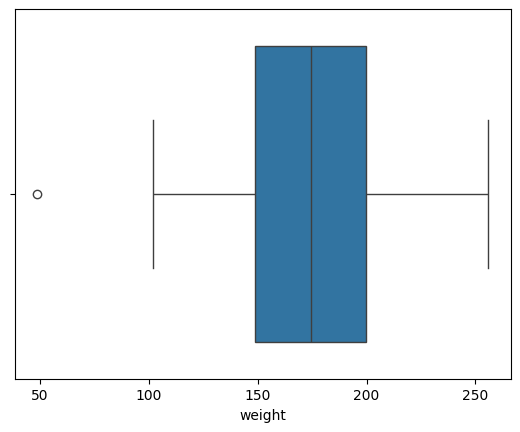

In [102]:
# code (outliers of weight)
sns.boxplot(data=patients_df, x="weight")
plt.show()

In [103]:
Q1 = patients_df['weight'].quantile(0.25)
Q3 = patients_df['weight'].quantile(0.75)

IQR = Q3 - Q1

lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR

lb, ub

(np.float64(72.47499999999994), np.float64(276.07500000000005))

In [104]:
patients_df.shape

(498, 15)

In [105]:
patients_df[(patients_df['weight'] > lb) & (patients_df['weight'] < ub)]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,Phone,Email
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,1976-07-10,121.7,66,19.6,951-719-9170,ZoeWellish@superrito.com
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,1967-04-03,118.8,66,19.2,+1 (217) 569-3204,PamelaSHill@cuvox.de
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,1980-02-19,177.8,71,24.8,402-363-6804,JaeMDebord@gustr.com
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,1951-07-26,220.9,70,31.7,+1 (732) 636-8246,PhanBaLiem@jourrapide.com
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,1928-02-18,192.3,27,26.1,334-515-7487,TimNeudorf@cuvox.de
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,1959-04-10,181.1,72,24.6,207-477-0579,MustafaLindstrom@jourrapide.com
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,1948-03-26,239.6,70,34.4,928-284-4492,RumanBisliev@gustr.com
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,1971-01-13,171.2,67,26.8,816-223-6007,JinkedeKeizer@teleworm.us
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,1952-02-13,176.9,67,27.7,1 360 443 2060,ChidaluOnyekaozulu@jourrapide.com


In [106]:
patients_df = patients_df[(patients_df['weight'] > lb) & (patients_df['weight'] < ub)]


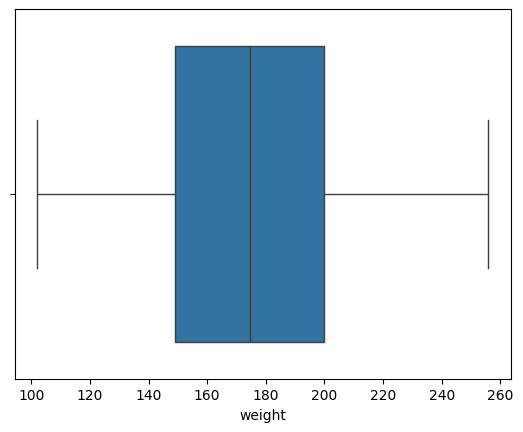

In [107]:
# test
sns.boxplot(data=patients_df, x="weight")
plt.show()

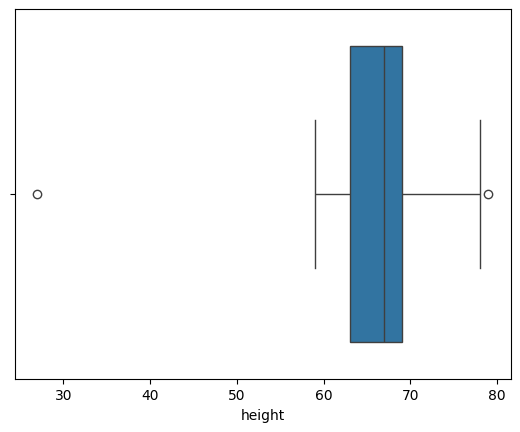

In [108]:
# code (remove outliers of height)
sns.boxplot(data=patients_df, x='height')
plt.show()

In [109]:
# here we can see there are outliers
q1_h = patients_df['height'].quantile(0.25)
q3_h = patients_df['height'].quantile(0.75)

iqr_h = q3_h - q1_h

lb_h = q1_h - 1.5 * iqr_h
ub_h = q3_h + 1.5 * iqr_h

lb_h, ub_h

(np.float64(54.0), np.float64(78.0))

In [110]:
patients_df.shape

(497, 15)

In [111]:
patients_df[(patients_df['height'] >= lb_h) & (patients_df['height'] <= ub_h)]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,Phone,Email
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,1976-07-10,121.7,66,19.6,951-719-9170,ZoeWellish@superrito.com
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,1967-04-03,118.8,66,19.2,+1 (217) 569-3204,PamelaSHill@cuvox.de
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,1980-02-19,177.8,71,24.8,402-363-6804,JaeMDebord@gustr.com
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,1951-07-26,220.9,70,31.7,+1 (732) 636-8246,PhanBaLiem@jourrapide.com
5,6,male,Rafael,Costa,1140 Willis Avenue,Daytona Beach,Florida,32114.0,United States,1931-08-31,183.9,70,26.4,386-334-5237,RafaelCardosoCosta@gustr.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,1959-04-10,181.1,72,24.6,207-477-0579,MustafaLindstrom@jourrapide.com
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,1948-03-26,239.6,70,34.4,928-284-4492,RumanBisliev@gustr.com
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,1971-01-13,171.2,67,26.8,816-223-6007,JinkedeKeizer@teleworm.us
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,1952-02-13,176.9,67,27.7,1 360 443 2060,ChidaluOnyekaozulu@jourrapide.com


In [112]:
patients_df = patients_df[(patients_df['height'] >= lb_h) & (patients_df['height'] <= ub_h)]

In [113]:
patients_df.shape

(495, 15)

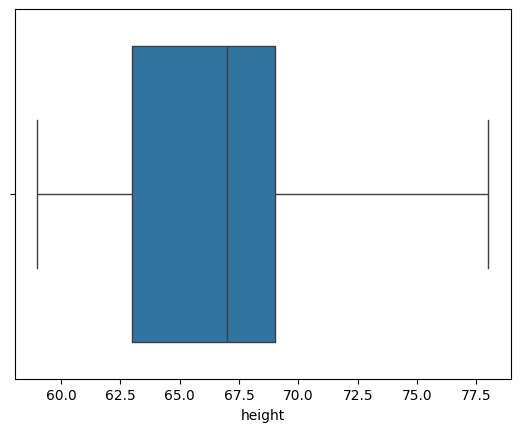

In [114]:
# test
sns.boxplot(data=patients_df, x='height')
plt.show()

In [115]:
# code (duplicate entry by the name Joseph day)
treatments_df[treatments_df.duplicated()]

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dose_type,dose_start,dose_end,adverse_reaction
62,joseph,day,7.7,7.19,0.51,auralin,29,36,hypoglycemia


In [116]:
treatments_df = treatments_df.drop_duplicates()

In [117]:
treatments_df[treatments_df.duplicated()]

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dose_type,dose_start,dose_end,adverse_reaction


In [118]:
# Test
treatments_df[treatments_df['given_name'] == 'joseph']

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dose_type,dose_start,dose_end,adverse_reaction
5,joseph,day,7.70,7.19,0.51,auralin,29,36,hypoglycemia
167,joseph,tucker,7.67,7.30,0.37,auralin,48,56,NaN


### Consistency issues
#### Define

Table - Patients

- state col sometimes contain full name and some times abbrivietation consistency  
  We converted the full names of city to abbrivations cause it is easy.

Table - Treatments & Treatments_cut

- given_name and surname col is is all lowercase consistency  
  Perform capitalize function on both column

Table - Adverse_reactions

- given_name and surname are all in lower case consistency

In [119]:
# code (state col contain abbrivations sometimes)
patients_df['state'].unique()

<StringArray>
['California',   'Illinois',   'Nebraska',         'NJ',    'Florida',
         'NV',         'CA',         'MO',   'New York',         'MI',
         'TN',         'VA',         'AL',         'OK',         'GA',
         'MT',         'MA',         'NY',         'NM',         'IL',
         'LA',         'PA',         'CO',         'ME',         'WI',
         'SD',         'MN',         'FL',         'WY',         'OH',
         'IA',         'NC',         'IN',         'CT',         'KY',
         'DE',         'MD',         'AZ',         'TX',         'NE',
         'AK',         'ND',         'KS',         'MS',         'WA',
         'SC',         'WV',         'RI',         'NH',         'OR',
    'No Data',         'VT',         'ID',         'DC',         'AR']
Length: 55, dtype: str

In [120]:
# Most of the time the state named as abbrivations so converting abbrivations to full name will take too much time so lets convert the names to abbrivations
state_mapping = {
    'California': 'CA',
    'Illinois': 'IL',
    'Nebraska': 'NE',
    'Florida': 'FL',
    'New York': 'NY'
}

In [121]:
patients_df['state'] = patients_df['state'].replace(state_mapping)

In [122]:
# test
patients_df['state'].unique()

<StringArray>
[     'CA',      'IL',      'NE',      'NJ',      'FL',      'NV',      'MO',
      'NY',      'MI',      'TN',      'VA',      'AL',      'OK',      'GA',
      'MT',      'MA',      'NM',      'LA',      'PA',      'CO',      'ME',
      'WI',      'SD',      'MN',      'WY',      'OH',      'IA',      'NC',
      'IN',      'CT',      'KY',      'DE',      'MD',      'AZ',      'TX',
      'AK',      'ND',      'KS',      'MS',      'WA',      'SC',      'WV',
      'RI',      'NH',      'OR', 'No Data',      'VT',      'ID',      'DC',
      'AR']
Length: 50, dtype: str

In [123]:
# code (names are all lowercase)
treatments_df['given_name'] = treatments_df['given_name'].str.capitalize()
treatments_df['surname'] = treatments_df['surname'].str.capitalize()

In [126]:
# test
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dose_type,dose_start,dose_end,adverse_reaction
0,Veronika,Jindrová,7.63,7.20,0.43,auralin,41,48,NaN
1,Skye,Gormanston,7.97,7.62,0.35,auralin,33,36,NaN
2,Sophia,Haugen,7.65,7.27,0.38,auralin,37,42,NaN
3,Eddie,Archer,7.89,7.55,0.34,auralin,31,38,NaN
4,Asia,Woźniak,7.76,7.37,0.39,auralin,30,36,NaN
...,...,...,...,...,...,...,...,...,...
345,Christopher,Woodward,7.51,7.06,0.45,novodra,55,51,nausea
346,Maret,Sultygov,7.67,7.30,0.37,novodra,26,23,NaN
347,Lixue,Hsueh,9.21,8.80,0.41,novodra,22,23,injection site discomfort
348,Jakob,Jakobsen,7.96,7.51,0.45,novodra,28,26,hypoglycemia


## Final cleaned Datasets

In [130]:
patients_df.to_csv(r'Cleaned/cleaned_patients.csv')
treatments_df.to_csv(r'Cleaned/cleaned_treatments.csv')